In [1]:
!pip install pymc arviz

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 11.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.3 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 36.4 MB/s eta 0:00:00
Using cached markdown_it_py-3.0.0-py3-none-any.whl (87 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.3 MB/s eta 0:00:00a 0:00:01
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
   ━━━━━━━━━━━━━━━

Initializing NUTS using jitter+adapt_diag...


  ridge_height torus_palatinus quality_of_life
0          low     not present    not improved
1         high          form A        improved
2          low     not present        improved
3          low          form A    not improved
4         flat          form B    not improved
   ridge_height torus_palatinus quality_of_life
0           low     not present    not improved
1          high          form A        improved
2           low     not present        improved
3           low          form A    not improved
4          flat          form B    not improved
..          ...             ...             ...
95          low     not present        improved
96          low          form A    not improved
97          low          form B        improved
98         flat          form B    not improved
99         flat          form A        improved

[100 rows x 3 columns]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_ridge, beta_torus]


/Users/janoskonig/anaconda3/envs/taf/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha         -0.410  0.837  -2.054    1.100      0.022    0.016    1455.0   
beta_ridge[0]  1.192  0.647  -0.016    2.403      0.016    0.011    1632.0   
beta_ridge[1]  0.870  0.663  -0.317    2.150      0.015    0.011    1870.0   
beta_ridge[2]  0.690  0.647  -0.455    1.978      0.016    0.011    1650.0   
beta_torus[0] -0.573  0.641  -1.776    0.590      0.014    0.010    1974.0   
beta_torus[1] -0.803  0.648  -1.973    0.440      0.015    0.010    1935.0   
beta_torus[2] -0.699  0.626  -1.869    0.445      0.015    0.010    1791.0   

               ess_tail  r_hat  
alpha            1717.0    1.0  
beta_ridge[0]    2191.0    1.0  
beta_ridge[1]    2449.0    1.0  
beta_ridge[2]    2244.0    1.0  
beta_torus[0]    1990.0    1.0  
beta_torus[1]    2383.0    1.0  
beta_torus[2]    1759.0    1.0  
Trace Plot


<Figure size 1200x800 with 0 Axes>

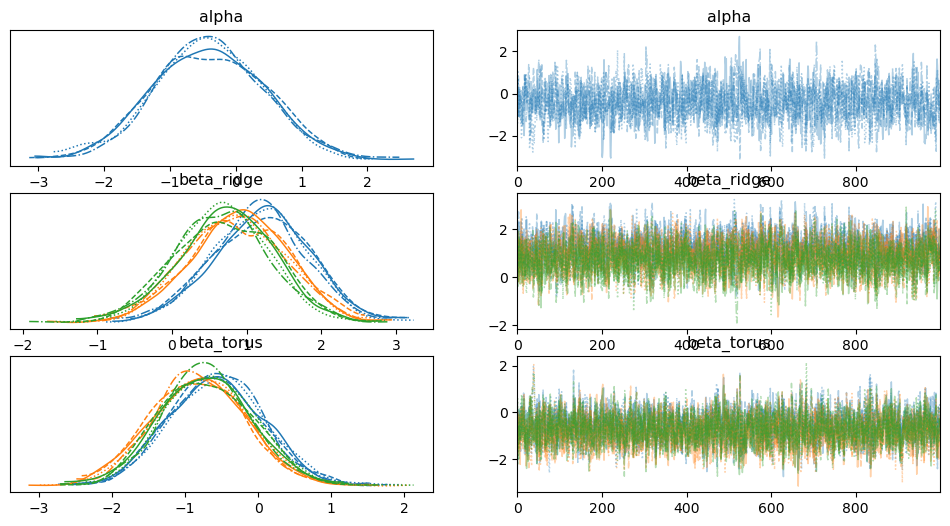

Posterior Distribution Plot


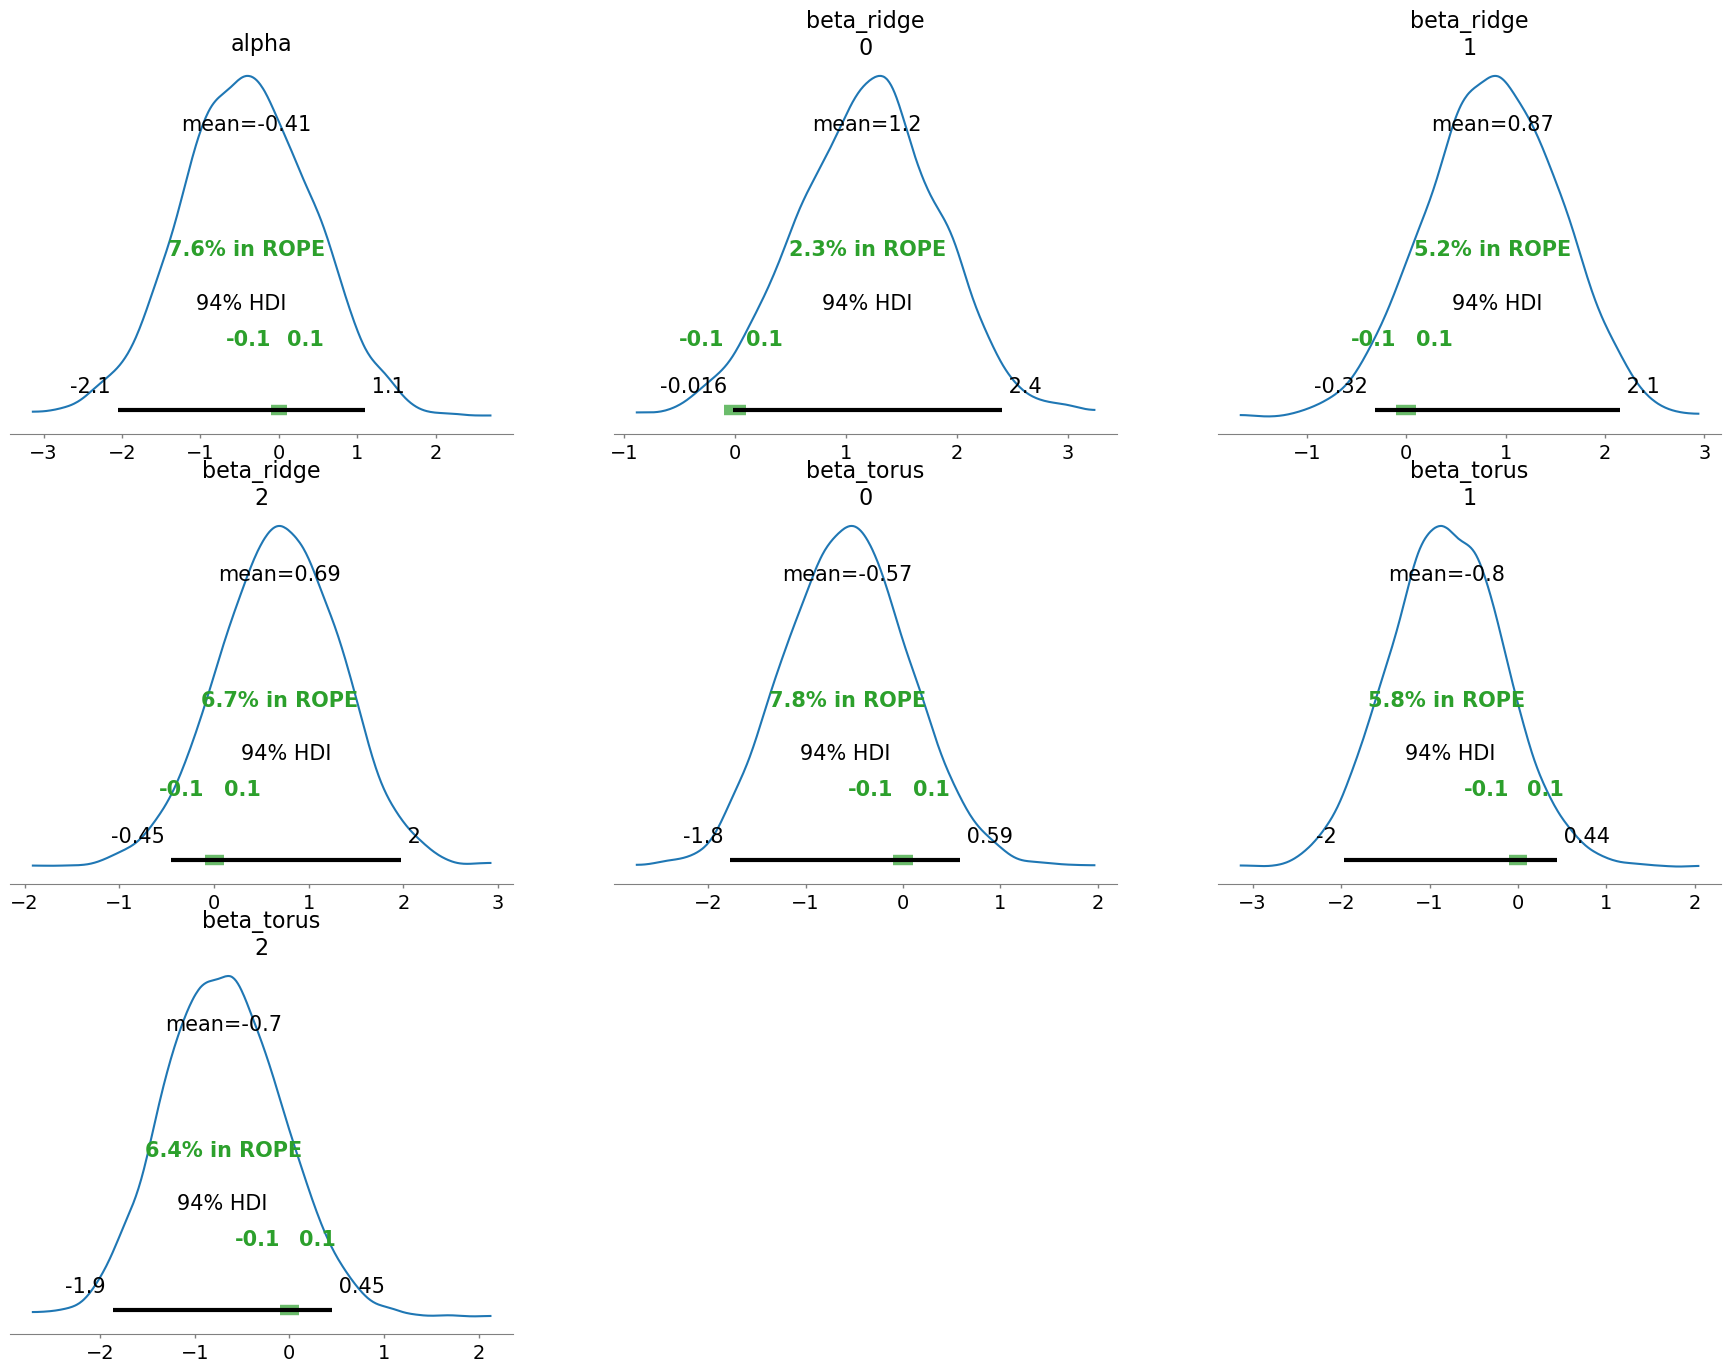

Forest Plot


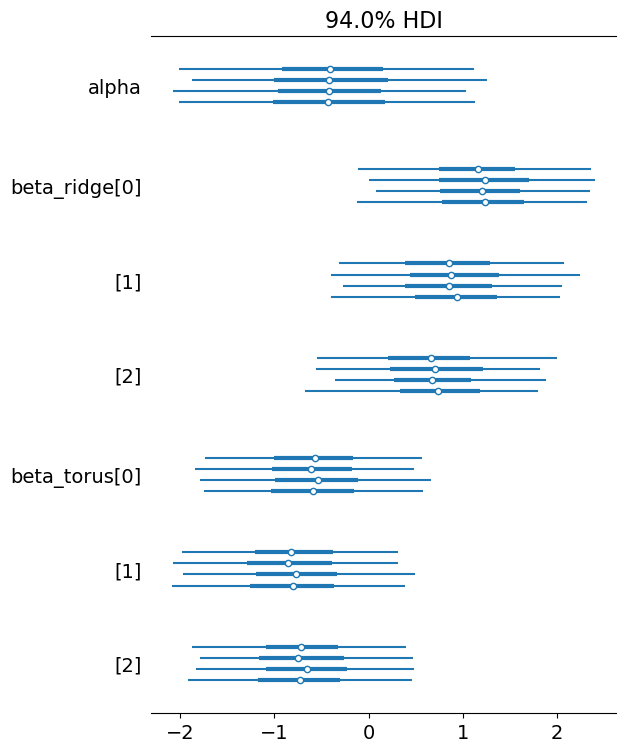

Pair Plot


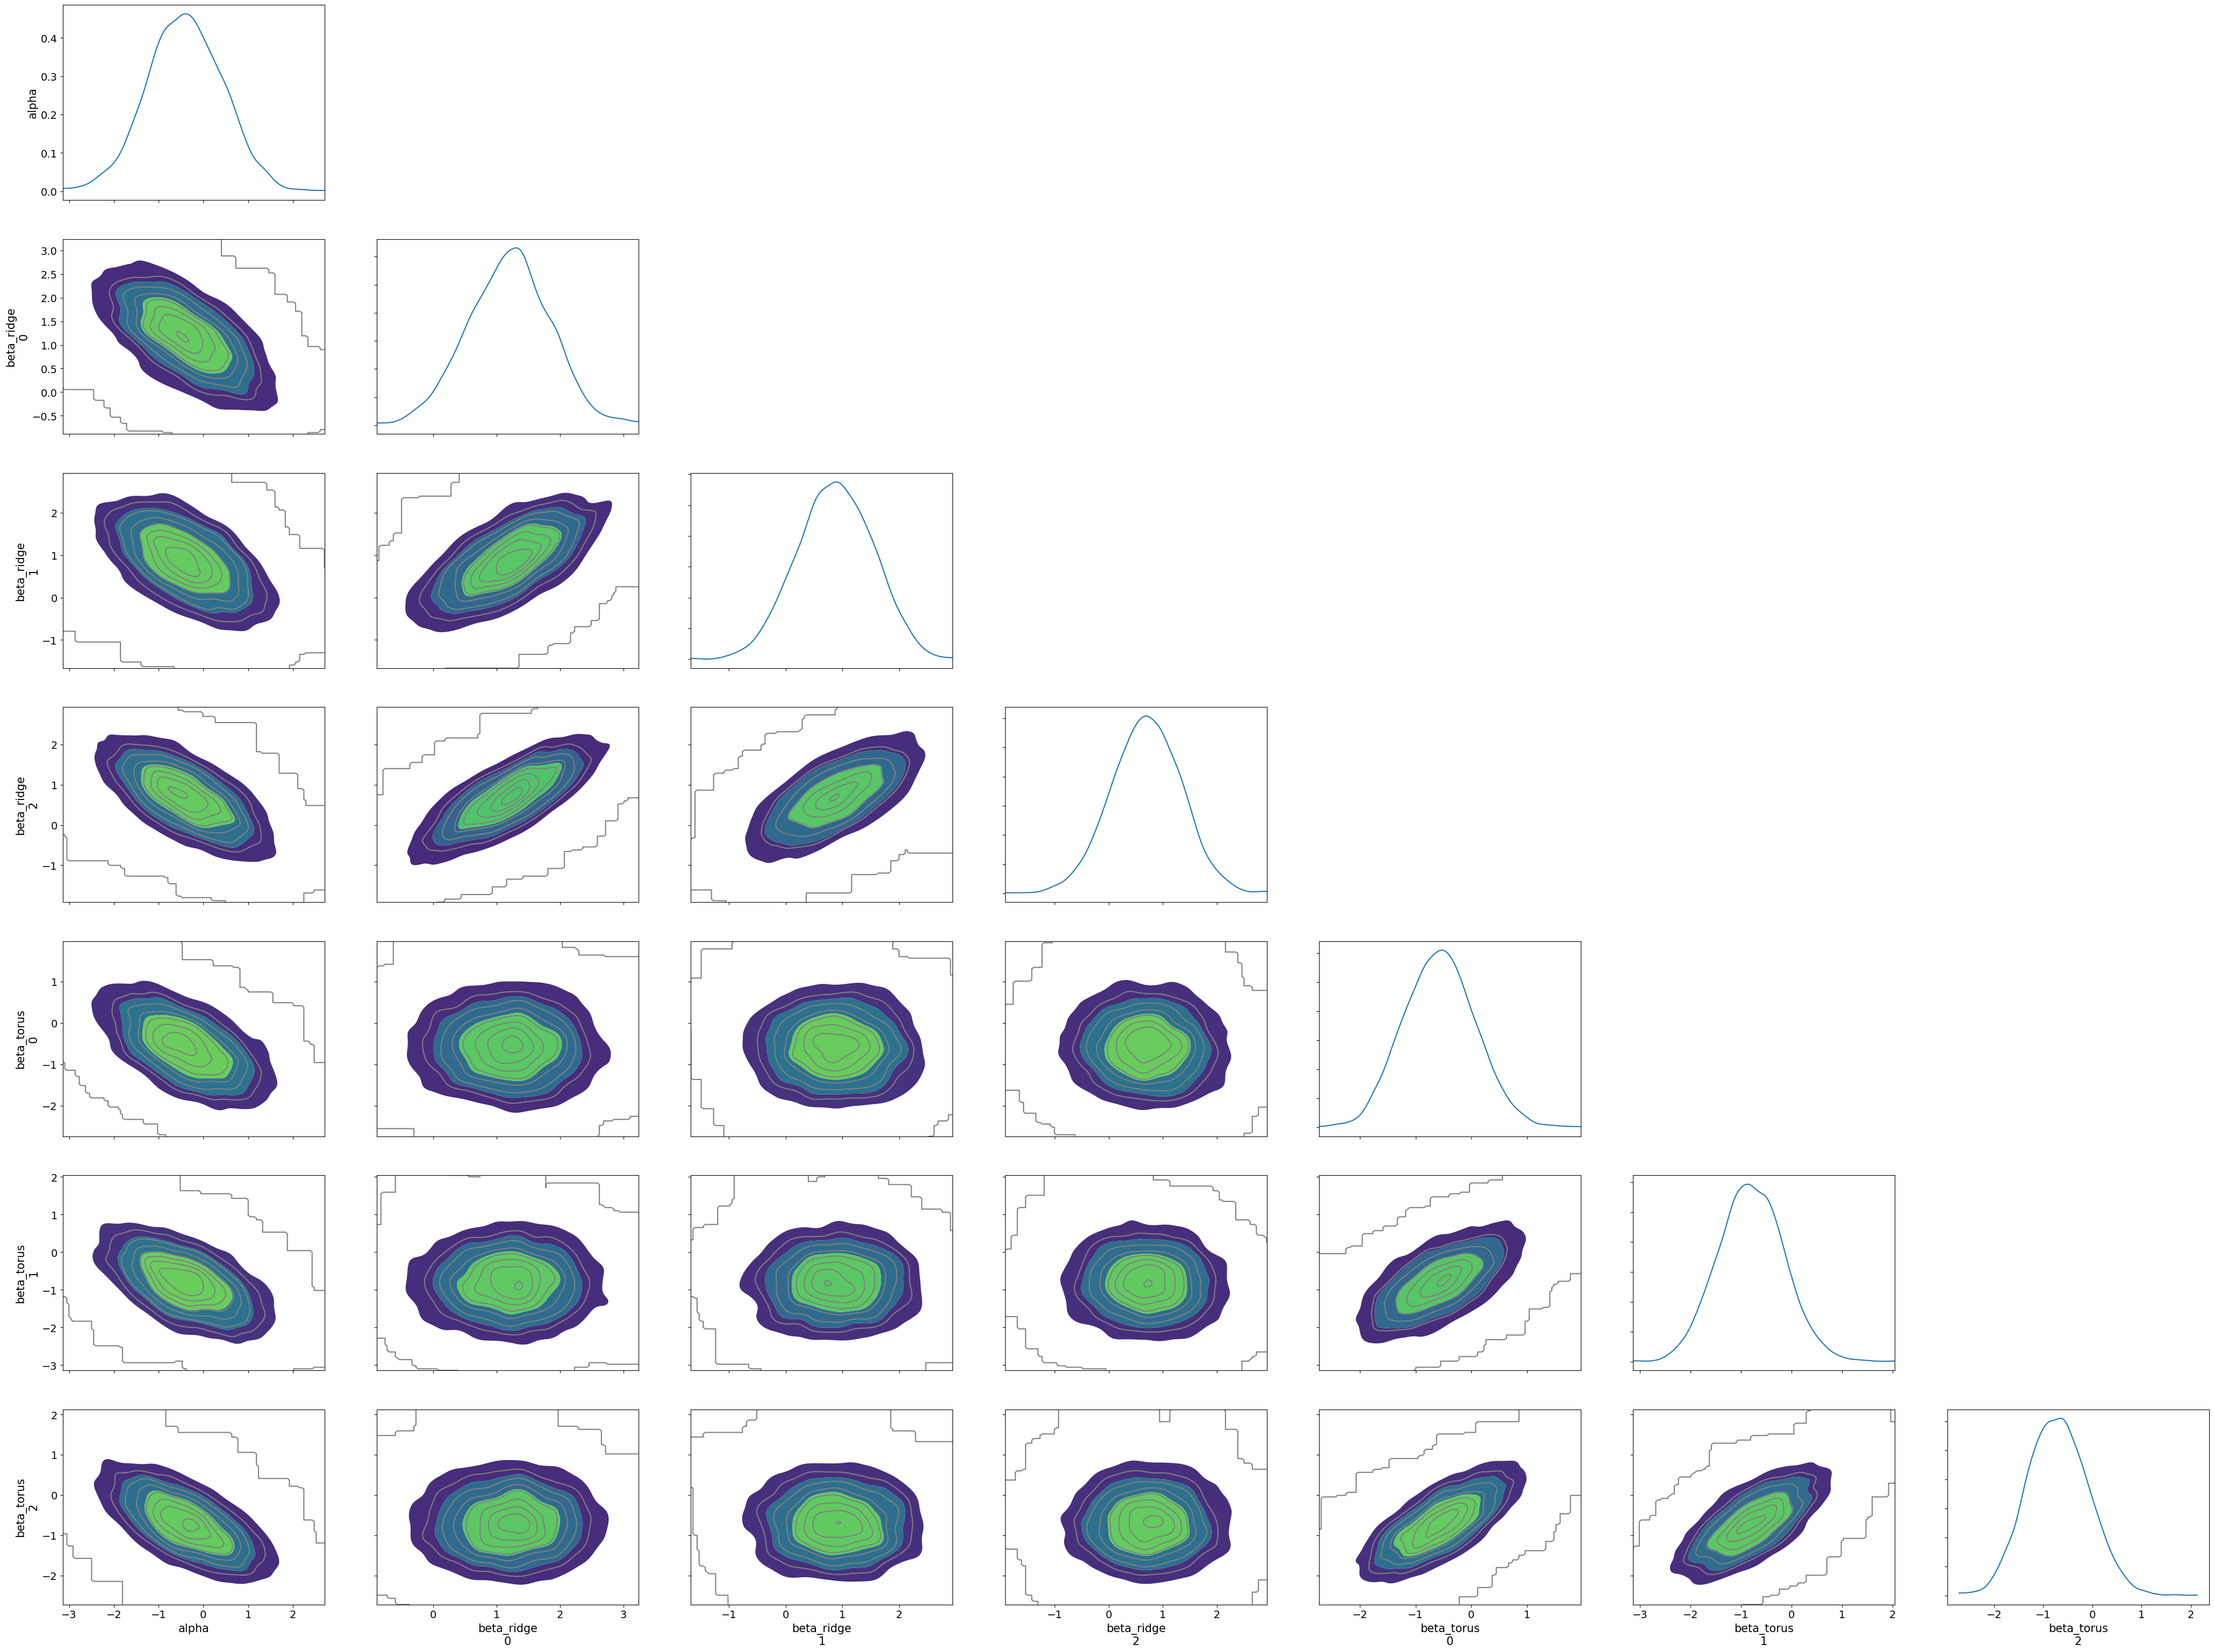

Rank Plot


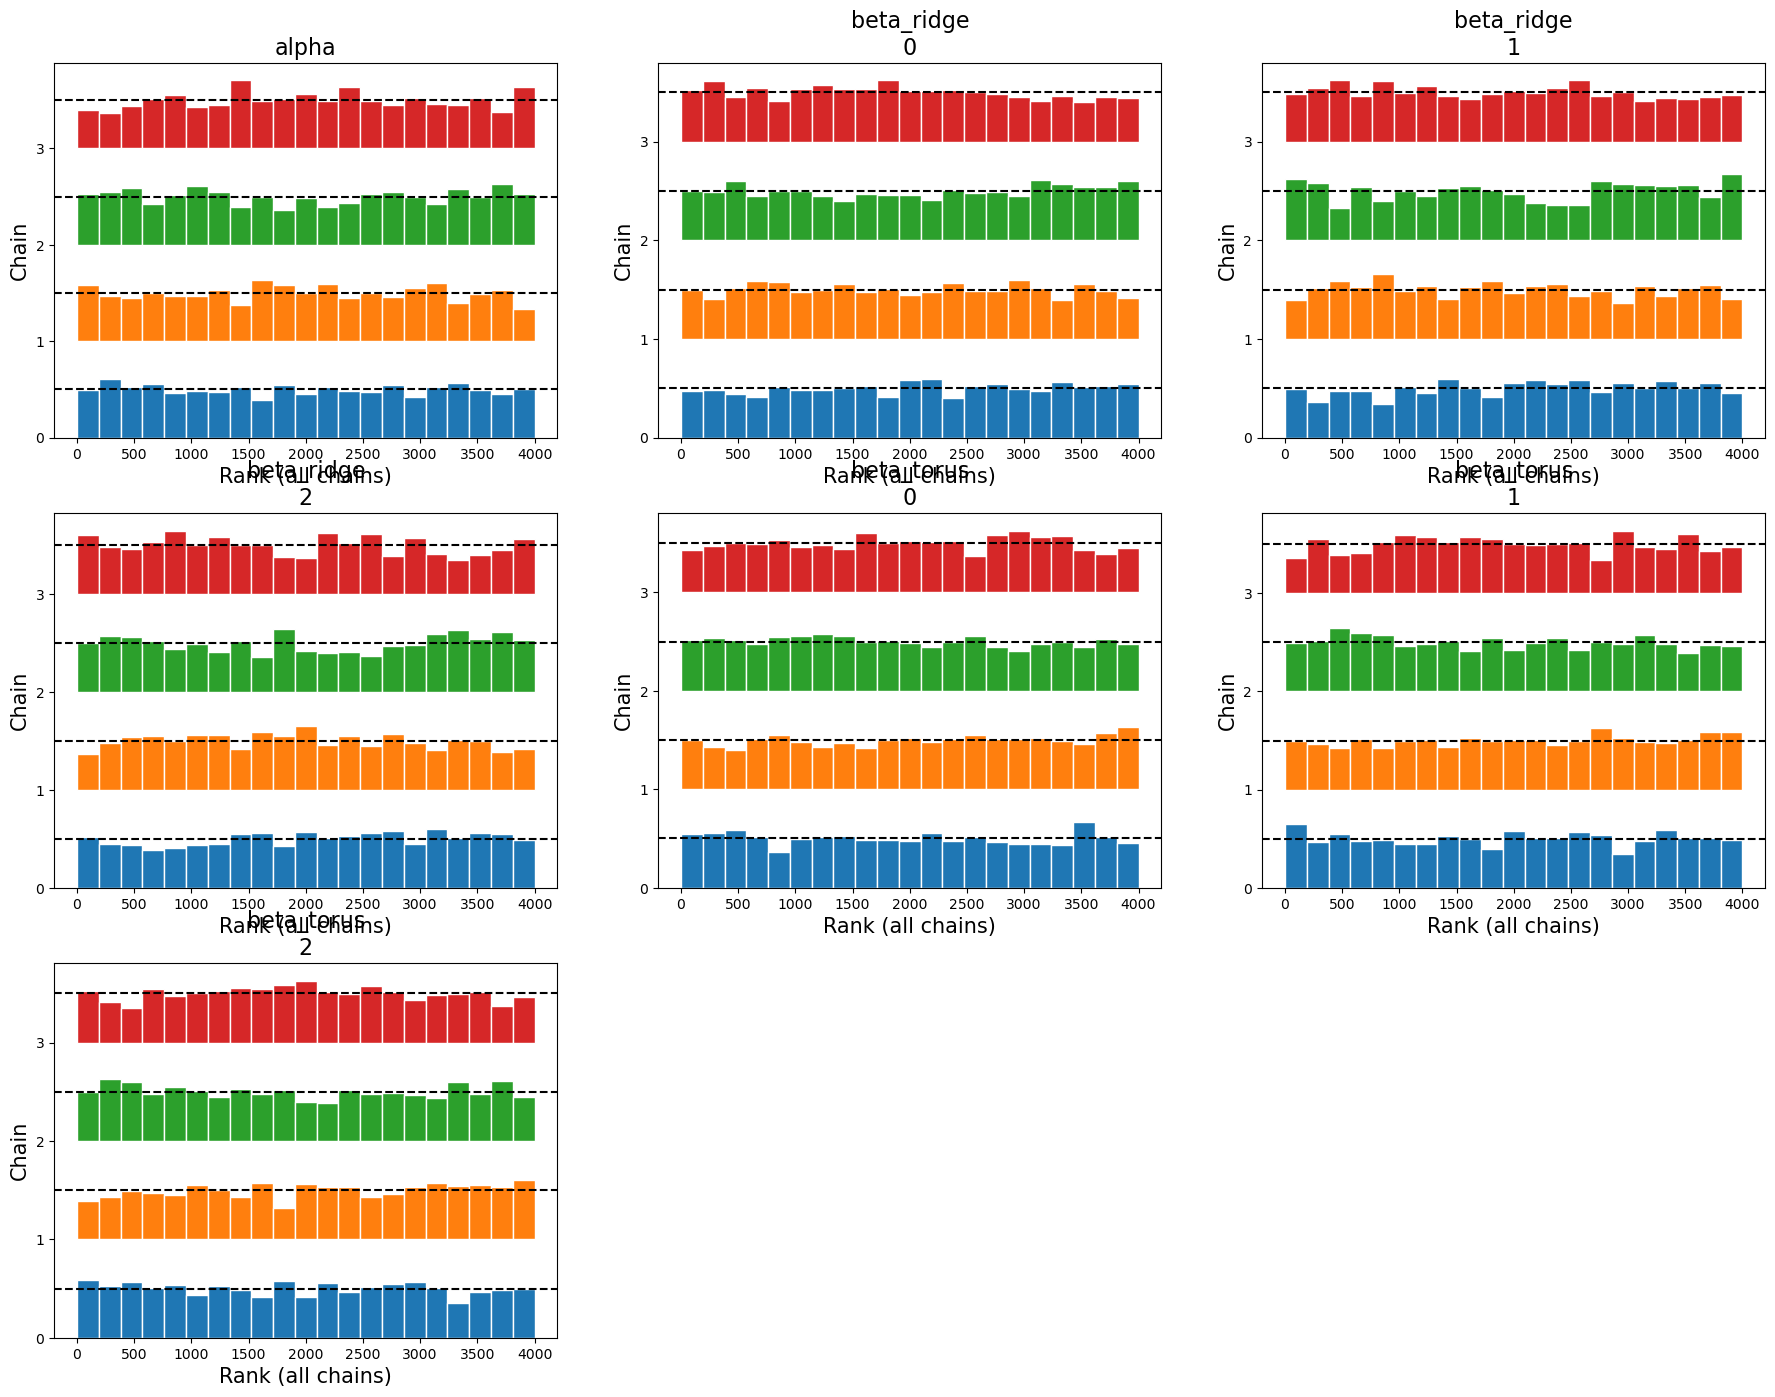

In [6]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Generate Dummy Data
np.random.seed(42)
ridge_height = np.random.choice(['flat', 'low', 'high'], size=100, p=[0.3, 0.5, 0.2])
torus_palatinus = np.random.choice(['not present', 'form A', 'form B'], size=100, p=[0.5, 0.3, 0.2])
quality_of_life = np.random.choice(['improved', 'not improved'], size=100, p=[0.6, 0.4])

data = pd.DataFrame({
    'ridge_height': ridge_height,
    'torus_palatinus': torus_palatinus,
    'quality_of_life': quality_of_life
})

print(data.head())

# Encode Categorical Variables
ridge_encoded = pd.Categorical(data['ridge_height']).codes
torus_encoded = pd.Categorical(data['torus_palatinus']).codes
outcome_encoded = pd.Categorical(data['quality_of_life']).codes

print(data)

# Build Bayesian Model
with pm.Model() as model:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta_ridge = pm.Normal('beta_ridge', mu=np.log(2.5), sigma=1, shape=len(set(ridge_encoded)))
    beta_torus = pm.Normal('beta_torus', mu=np.log(0.5), sigma=1, shape=len(set(torus_encoded)))
    mu = alpha + beta_ridge[ridge_encoded] + beta_torus[torus_encoded]
    theta = pm.math.sigmoid(mu)
    y_obs = pm.Bernoulli('y_obs', p=theta, observed=outcome_encoded)

    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.9)

# Summary
summary = az.summary(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'])
print(summary)

# Visualizations
plt.figure(figsize=(12, 8))

# 1. Trace Plot
print('Trace Plot')
az.plot_trace(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'])
plt.show()

# 2. Posterior Distribution Plot
print('Posterior Distribution Plot')
az.plot_posterior(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'], rope=(-0.1, 0.1))
plt.show()

# 3. Forest Plot
print('Forest Plot')
az.plot_forest(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'])
plt.show()

# 4. Pair Plot
print('Pair Plot')
az.plot_pair(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'], kind='kde', marginals=True)
plt.show()

# 5. Rank Plot
print('Rank Plot')
az.plot_rank(trace, var_names=['alpha', 'beta_ridge', 'beta_torus'])
plt.show()